# AutoValue : ML Powered Used Car Price Predictor

---
**Author:** Austin Silitonga  
**Dataset:** [Kaggle — Car Price Prediction Dataset](https://www.kaggle.com/datasets/sukhmandeepsinghbrar/car-price-prediction-dataset)  
**Goal:** Predict the selling price of a used car.

---

# Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from feature_engine.outliers import Winsorizer
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
%pip install category_encoders
import category_encoders as ce
from sklearn.model_selection import RandomizedSearchCV
import pickle
import warnings
warnings.filterwarnings("ignore")

Note: you may need to restart the kernel to use updated packages.


In [10]:
import sklearn
format(sklearn.__version__)

'1.5.1'

# Data Loading

In this section, we load the dataset, define the meaning of each column, and do a quick exploration of the data.

In [2]:
# load dataset
df = pd.read_csv('cardekho.csv')

df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110,5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.9,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0


Definisi Kolom :

| Column Name | Meaning / Definition |
| :--- | :--- |
| **`name`** | Full car name (Brand, Model, Variant). |
| **`year`** | Year the car was manufactured or first registered. |
| **`selling_price`** | Listed selling price of the used car (in Indian Rupee - INR). |
| **`km_driven`** | Total mileage of the car (in kilometers). |
| **`fuel`** | Type of fuel the car uses. |
| **`seller_type`** | Category of the car seller. |
| **`transmission`** | Type of transmission system. |
| **`owner`** | Ownership history of the car. |
| **`mileage(km/ltr/kg)`** | Fuel efficiency of the car. Can be km/ltr for petrol and km/kg for CNG. |
| **`engine`** | Engine capacity of the car. |
| **`max_power`** | Maximum power output of the engine. |
| **`seats`** | Number of passenger seats in the car. |

In [3]:
#cek duplikasi data
df.duplicated().sum()

1202

In [4]:
# drop data duplikat
df.drop_duplicates(inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                6926 non-null   object 
 1   year                6926 non-null   int64  
 2   selling_price       6926 non-null   int64  
 3   km_driven           6926 non-null   int64  
 4   fuel                6926 non-null   object 
 5   seller_type         6926 non-null   object 
 6   transmission        6926 non-null   object 
 7   owner               6926 non-null   object 
 8   mileage(km/ltr/kg)  6718 non-null   float64
 9   engine              6718 non-null   float64
 10  max_power           6721 non-null   object 
 11  seats               6718 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 703.4+ KB


In [6]:
# cek missing value
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    208
engine                208
max_power             205
seats                 208
dtype: int64

In [7]:
# memperpendek nama kolom mileage
df.rename(columns={
    'mileage(km/ltr/kg)' : 'mileage'
}, inplace=True)

From the initial exploration, we found that some numeric columns have incorrect data types, and there are several missing values in the dataset. We will handle these in the Exploratory Data Analysis section for further analysis.

# Exploratory Data Analysis

In this section, we will do a deeper exploration of the used car dataset we have.

In [8]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   object 
 1   year           6926 non-null   int64  
 2   selling_price  6926 non-null   int64  
 3   km_driven      6926 non-null   int64  
 4   fuel           6926 non-null   object 
 5   seller_type    6926 non-null   object 
 6   transmission   6926 non-null   object 
 7   owner          6926 non-null   object 
 8   mileage        6718 non-null   float64
 9   engine         6718 non-null   float64
 10  max_power      6721 non-null   object 
 11  seats          6718 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 703.4+ KB


## Handling Data Type

We convert the max_power column from object type to numeric type.

In [10]:
df['max_power'].unique()

array(['74', '103.52', '78', '90', '88.2', '81.86', '57.5', '37', '67.1',
       '68.1', '108.45', '60', '73.9', nan, '67', '82', '88.5', '46.3',
       '88.73', '64.1', '98.6', '88.8', '83.81', '83.1', '47.3', '73.8',
       '34.2', '35', '81.83', '40.3', '121.3', '138.03', '160.77',
       '117.3', '116.3', '83.14', '67.05', '168.5', '100', '120.7',
       '98.63', '175.56', '103.25', '171.5', '100.6', '174.33', '187.74',
       '170', '78.9', '88.76', '86.8', '108.495', '108.62', '93.7',
       '103.6', '98.59', '189', '67.04', '68.05', '58.2', '82.85', '81.8',
       '73', '120', '94.68', '160', '65', '155', '69.01', '126.32',
       '138.1', '83.8', '126.2', '98.96', '62.1', '86.7', '188', '214.56',
       '177', '280', '148.31', '254.79', '190', '177.46', '204', '141',
       '117.6', '241.4', '282', '150', '147.5', '108.5', '103.5', '183',
       '181.04', '157.7', '164.7', '91.1', '400', '68', '75', '85.8',
       '87.2', '53', '118', '103.2', '83', '84', '58.16', '147.94',
   

In [11]:
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   object 
 1   year           6926 non-null   int64  
 2   selling_price  6926 non-null   int64  
 3   km_driven      6926 non-null   int64  
 4   fuel           6926 non-null   object 
 5   seller_type    6926 non-null   object 
 6   transmission   6926 non-null   object 
 7   owner          6926 non-null   object 
 8   mileage        6718 non-null   float64
 9   engine         6718 non-null   float64
 10  max_power      6720 non-null   float64
 11  seats          6718 non-null   float64
dtypes: float64(4), int64(3), object(5)
memory usage: 703.4+ KB


## Handling Missing Value For EDA

In [13]:
# copy dataset untuk keperluan EDA
df_eda = df.copy()

In [14]:
df_eda.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          208
engine           208
max_power        206
seats            208
dtype: int64

There are missing values in the mileage, engine, max_power, and seats columns. These are important features for assessing car quality. Therefore, we will drop rows with incomplete data to avoid distorting the analysis.

In [15]:
#drop missing value
df_eda.dropna(inplace=True)

In [16]:
df_eda.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
seats            0
dtype: int64

In [17]:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
year,6717.0,2013.611136,3.897402,1994.0,2011.0,2014.00,2017.0,2020.0
selling_price,6717.0,526385.997022,523550.448297,29999.0,250000.0,420000.00,650000.0,10000000.0
km_driven,6717.0,73398.337651,58703.275270,1.0,38000.0,68203.00,100000.0,2360457.0
mileage,6717.0,19.466585,4.048102,0.0,16.8,19.44,22.5,42.0
engine,6717.0,1430.985857,493.469198,624.0,1197.0,1248.00,1498.0,3604.0
max_power,6717.0,87.766100,31.724555,32.8,67.1,81.83,100.0,400.0
seats,6717.0,5.434271,0.983805,2.0,5.0,5.00,5.0,14.0


In [18]:
df_eda[df_eda['mileage']==0].shape[0]

15

The description above shows that there are some rows with a mileage value of 0 km/ltr/kg, which is physically impossible for a car. There are only 15 rows with this value. We assume this is a data entry error (non-standard missing value), so we will drop these rows.

In [19]:
# drop data yang memiliki nilai mileage = 0
df_eda = df_eda[df_eda['mileage']!=0]

df_eda.shape[0]

6702

## Analisis Distribusi Harga

In [20]:
df_eda['selling_price'].describe()

count    6.702000e+03
mean     5.260229e+05
std      5.224831e+05
min      2.999900e+04
25%      2.500000e+05
50%      4.200000e+05
75%      6.500000e+05
max      1.000000e+07
Name: selling_price, dtype: float64

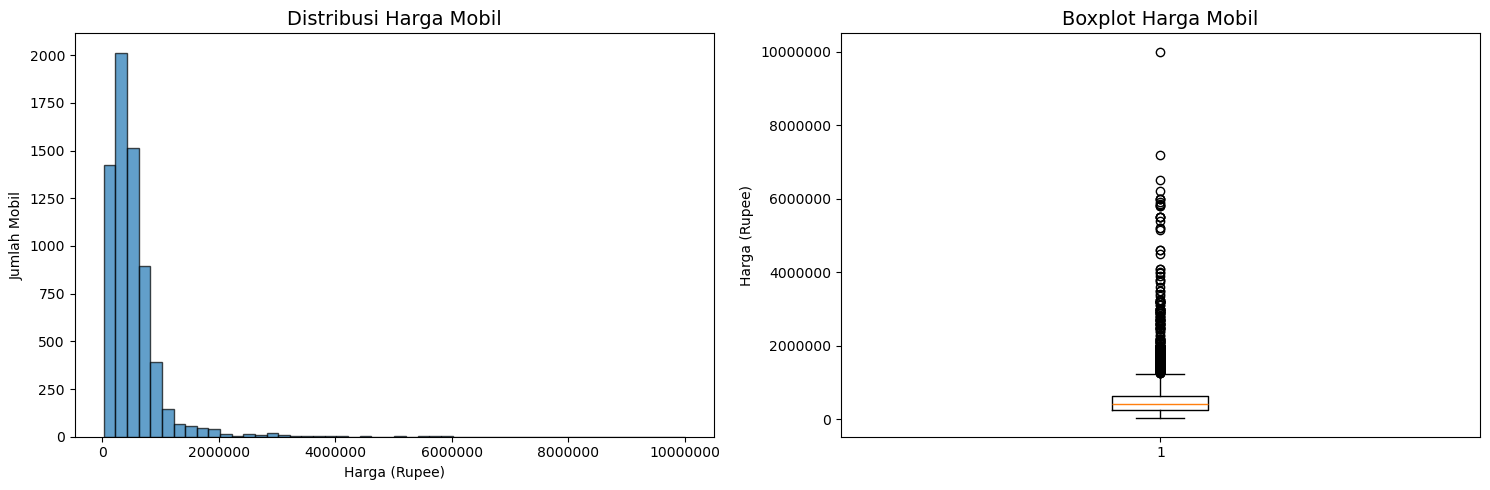

In [21]:
# Visualisasi distribusi harga
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df_eda['selling_price'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribusi Harga Mobil', fontsize=14)
axes[0].set_xlabel('Harga (Rupee)')
axes[0].set_ylabel('Jumlah Mobil')
axes[0].ticklabel_format(style='plain', axis='x')

# Boxplot
axes[1].boxplot(df_eda['selling_price'])
axes[1].set_title('Boxplot Harga Mobil', fontsize=14)
axes[1].set_ylabel('Harga (Rupee)')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

## Analisis Kolom Kategori

ANALISIS Jenis Bahan Bakar
        Jumlah  Persentase
fuel                      
Diesel    3653        54.5
Petrol    2963        44.2
CNG         51         0.8
LPG         35         0.5



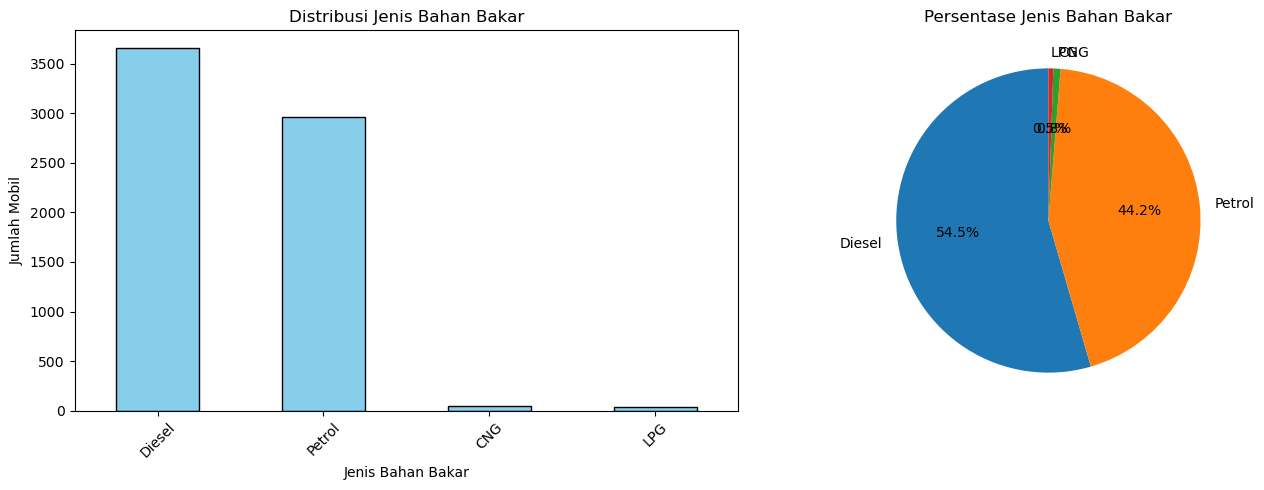

ANALISIS Tipe Penjual
                  Jumlah  Persentase
seller_type                         
Individual          6013        89.7
Dealer               662         9.9
Trustmark Dealer      27         0.4



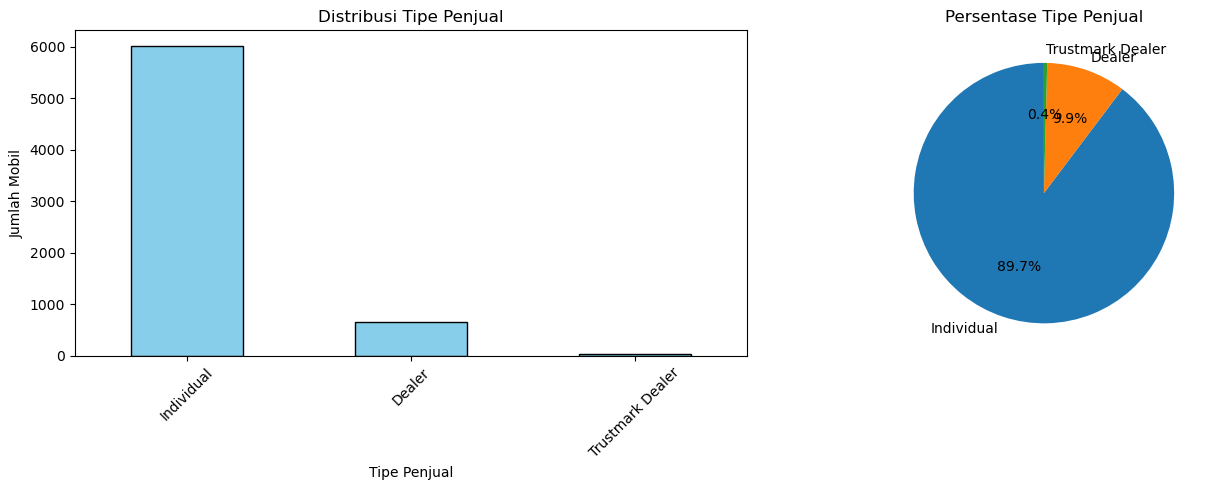

ANALISIS Transmisi
              Jumlah  Persentase
transmission                    
Manual          6132        91.5
Automatic        570         8.5



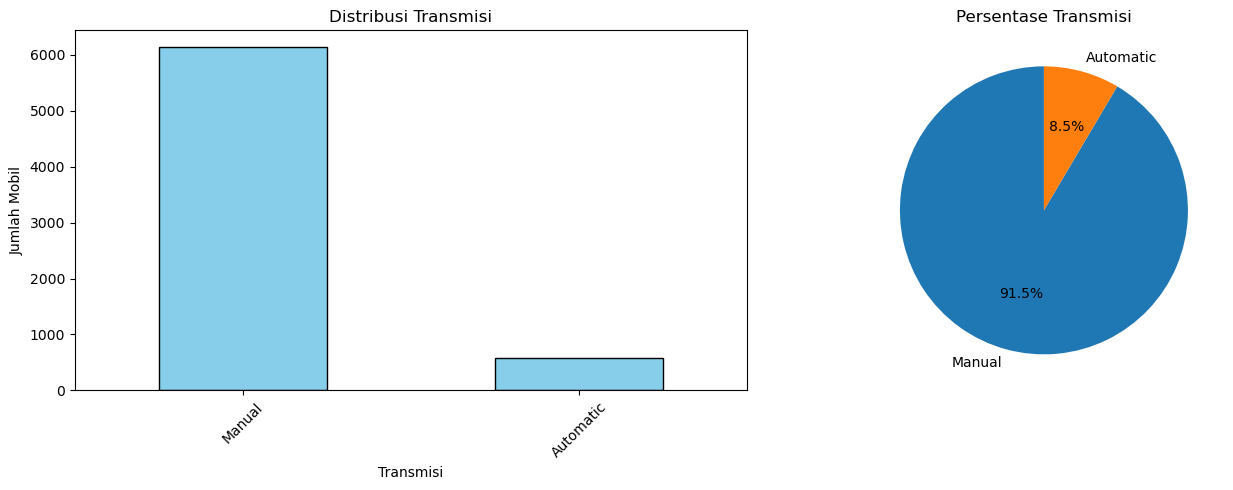

ANALISIS Riwayat Kepemilikan
                      Jumlah  Persentase
owner                                   
First Owner             4166        62.2
Second Owner            1885        28.1
Third Owner              492         7.3
Fourth & Above Owner     154         2.3
Test Drive Car             5         0.1



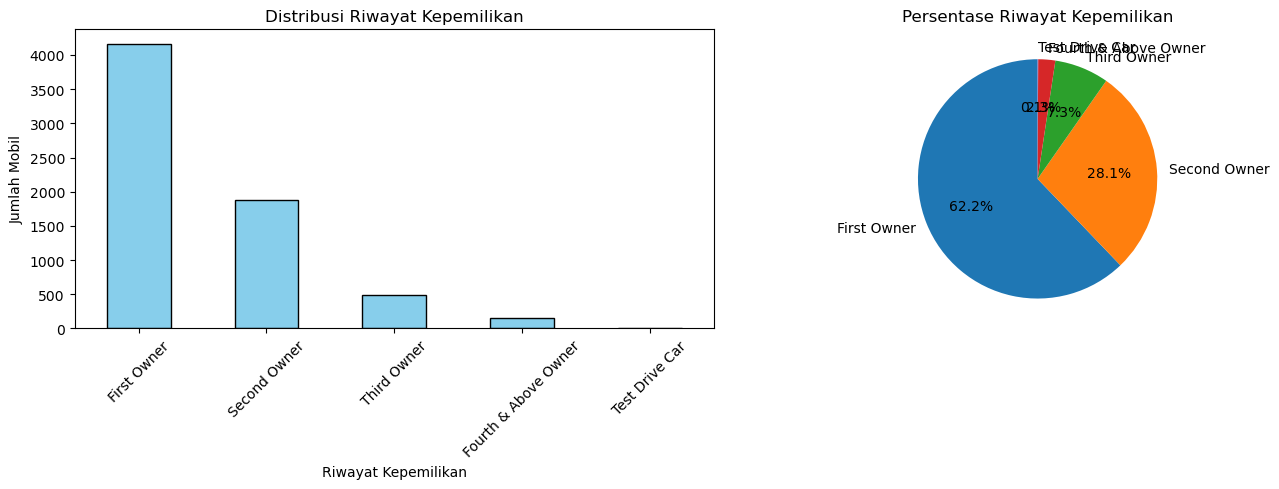

In [22]:
# Function untuk membuat ringkasan kategori
def analisis_kategori(kolom, title):
    print("="*50)
    print(f"ANALISIS {title}")
    print("="*50)
    
    # Hitung frekuensi
    freq = df_eda[kolom].value_counts()
    persen = df_eda[kolom].value_counts(normalize=True) * 100
    
    # Gabungkan
    summary = pd.DataFrame({
        'Jumlah': freq,
        'Persentase': persen.round(1)
    })
    print(summary)
    print()
    
    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Barplot
    freq.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title(f'Distribusi {title}', fontsize=12)
    axes[0].set_xlabel(title)
    axes[0].set_ylabel('Jumlah Mobil')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Pie chart
    axes[1].pie(freq.values, labels=freq.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Persentase {title}', fontsize=12)
    
    plt.tight_layout()
    plt.show()

# Analisis setiap fitur kategorikal penting
analisis_kategori('fuel', 'Jenis Bahan Bakar')
analisis_kategori('seller_type', 'Tipe Penjual')
analisis_kategori('transmission', 'Transmisi')
analisis_kategori('owner', 'Riwayat Kepemilikan')

## Analisis Kolom Numerik

STATISTIK FITUR NUMERIK
              year     km_driven       engine    max_power        seats  \
count  6702.000000  6.702000e+03  6702.000000  6702.000000  6702.000000   
mean   2013.613847  7.342715e+04  1430.707550    87.765621     5.436138   
std       3.897405  5.874013e+04   493.016491    31.703000     0.982929   
min    1994.000000  1.000000e+00   624.000000    32.800000     4.000000   
25%    2011.000000  3.800000e+04  1197.000000    68.000000     5.000000   
50%    2014.000000  6.837950e+04  1248.000000    81.830000     5.000000   
75%    2017.000000  1.000000e+05  1498.000000   100.000000     5.000000   
max    2020.000000  2.360457e+06  3604.000000   400.000000    14.000000   

           mileage  
count  6702.000000  
mean     19.510154  
std       3.946346  
min       9.000000  
25%      16.800000  
50%      19.490000  
75%      22.540000  
max      42.000000  



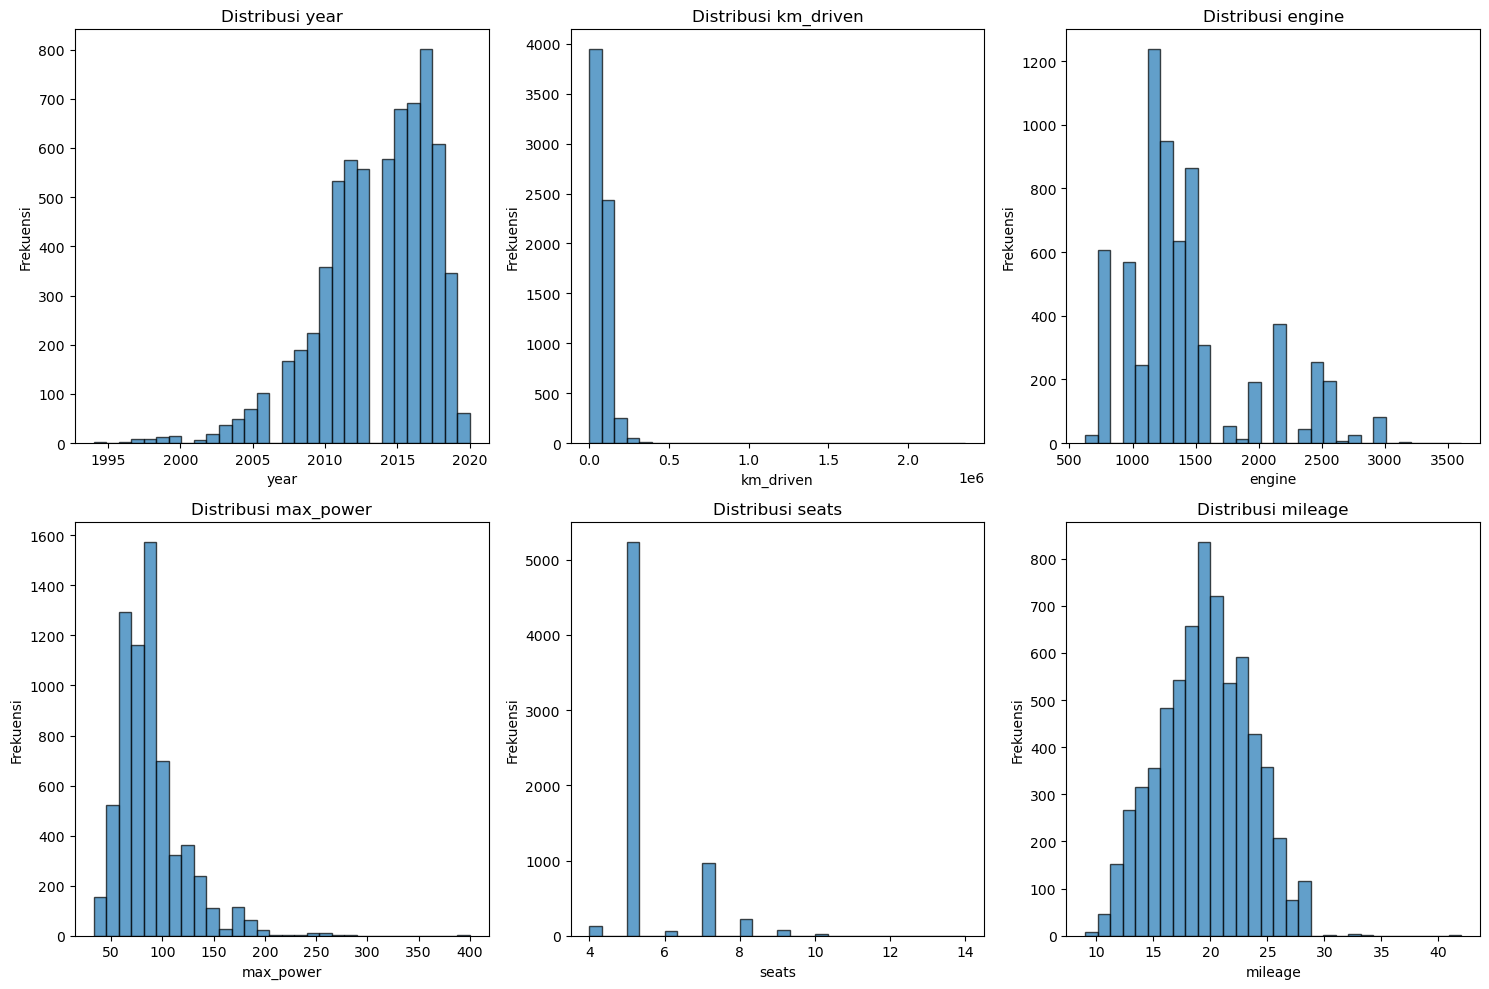

In [23]:
# Daftar fitur numerik (selain selling_price)
kolom_numerik = ['year', 'km_driven', 'engine', 'max_power', 'seats','mileage']

# Statistik deskriptif
print("="*50)
print("STATISTIK FITUR NUMERIK")
print("="*50)
print(df_eda[kolom_numerik].describe())
print()

# Visualisasi distribusi
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, kolom in enumerate(kolom_numerik):
    axes[i].hist(df_eda[kolom].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {kolom}', fontsize=12)
    axes[i].set_xlabel(kolom)
    axes[i].set_ylabel('Frekuensi')

# Hapus subplot yang tidak terpakai
for j in range(len(kolom_numerik), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Analisa Korelasi dengan Harga Mobil

KORELASI DENGAN HARGA (FITUR NUMERIK)
selling_price    1.000000
year             0.689430
max_power        0.633533
engine           0.480506
seats            0.320787
mileage          0.024052
km_driven       -0.282448
Name: selling_price, dtype: float64



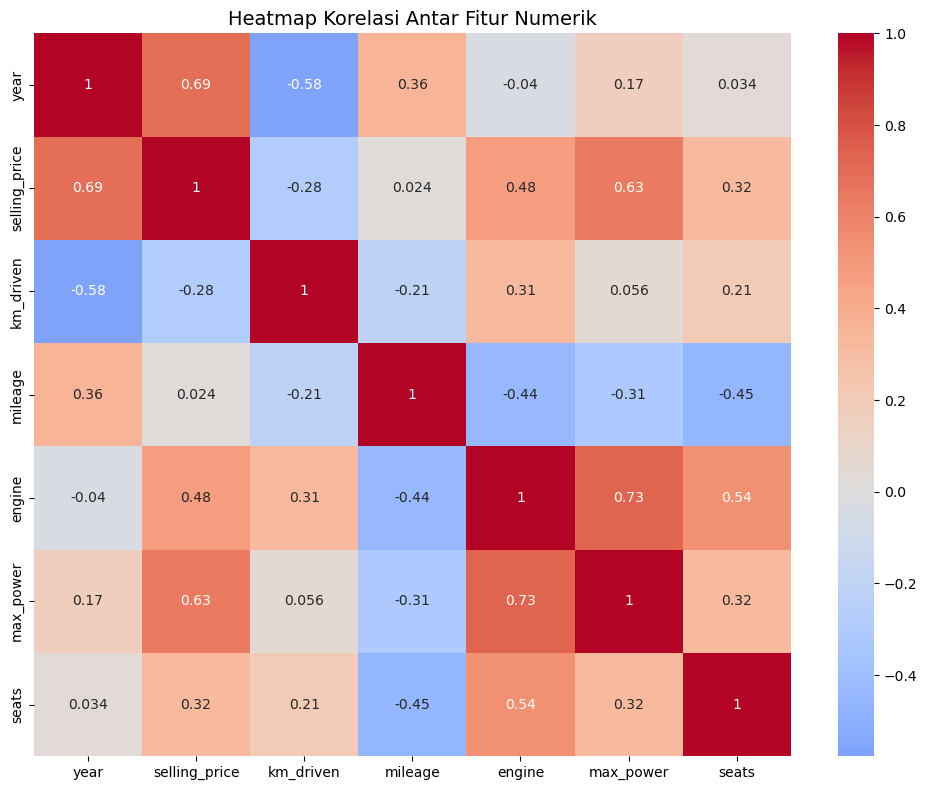

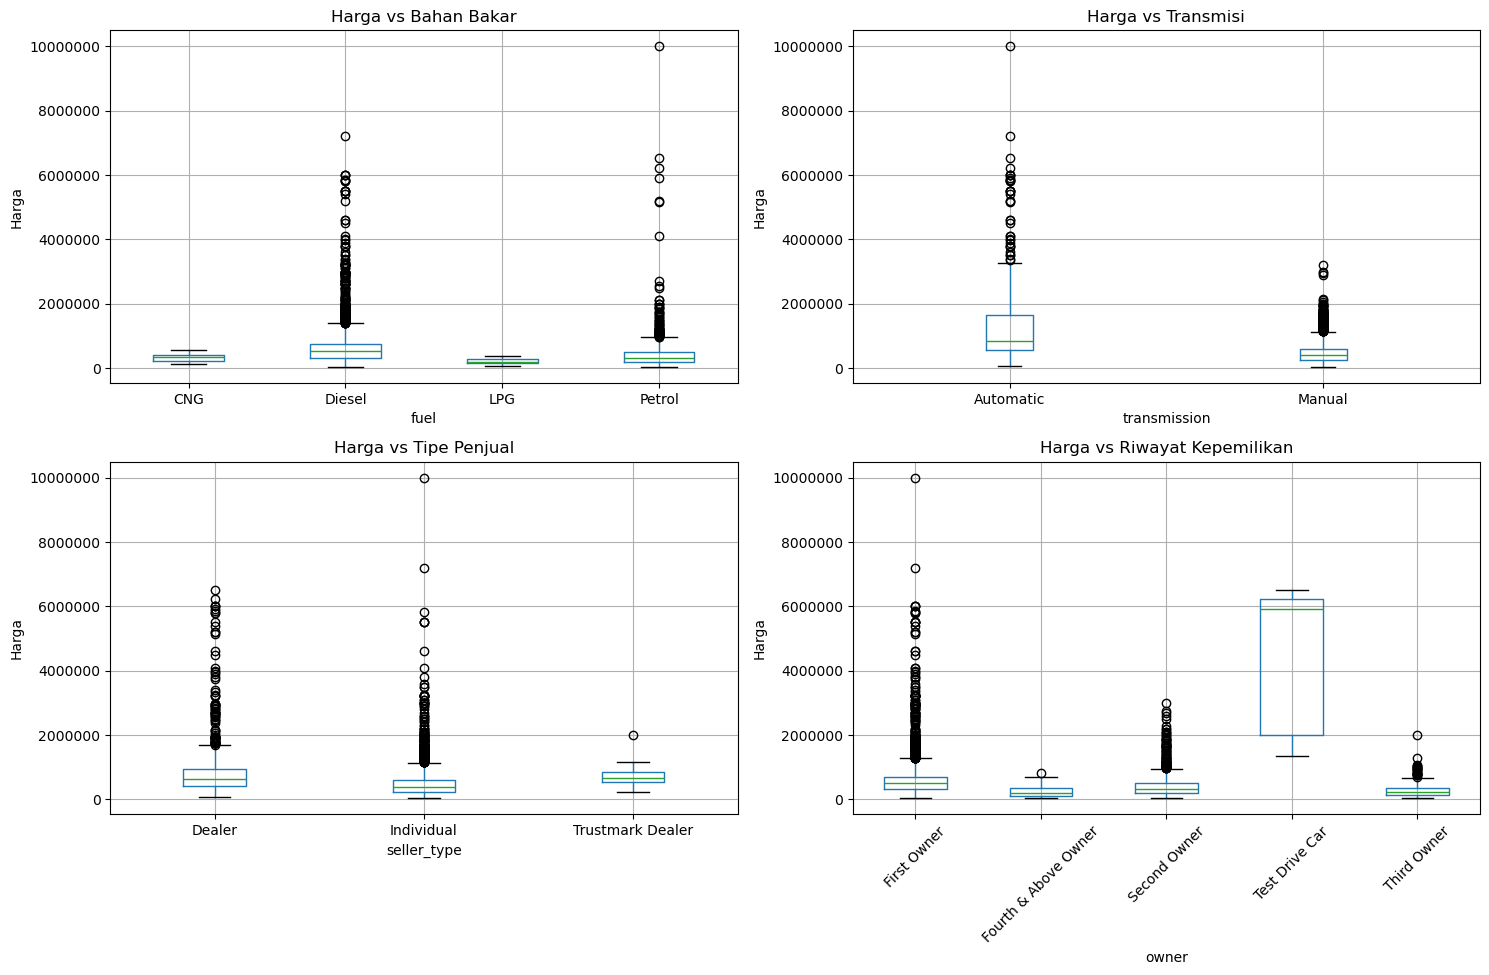

In [24]:
# Korelasi dengan fitur numerik
print("="*50)
print("KORELASI DENGAN HARGA (FITUR NUMERIK)")
print("="*50)

# Pilih kolom numerik saja
numeric_cols = df_eda.select_dtypes(include=[np.number]).columns
correlation = df_eda[numeric_cols].corr(method='spearman')['selling_price'].sort_values(ascending=False)
print(correlation)
print()

# Heatmap korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(df_eda[numeric_cols].corr(method='spearman'), annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Antar Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

# Boxplot: Harga berdasarkan kolom kategori
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Harga berdasarkan bahan bakar
df_eda.boxplot(column='selling_price', by='fuel', ax=axes[0,0])
axes[0,0].set_title('Harga vs Bahan Bakar')
axes[0,0].set_ylabel('Harga')
axes[0,0].ticklabel_format(style='plain', axis='y')

# Harga berdasarkan transmisi
df_eda.boxplot(column='selling_price', by='transmission', ax=axes[0,1])
axes[0,1].set_title('Harga vs Transmisi')
axes[0,1].set_ylabel('Harga')
axes[0,1].ticklabel_format(style='plain', axis='y')

# Harga berdasarkan tipe penjual
df_eda.boxplot(column='selling_price', by='seller_type', ax=axes[1,0])
axes[1,0].set_title('Harga vs Tipe Penjual')
axes[1,0].set_ylabel('Harga')
axes[1,0].ticklabel_format(style='plain', axis='y')

# Harga berdasarkan kepemilikan
df_eda.boxplot(column='selling_price', by='owner', ax=axes[1,1])
axes[1,1].set_title('Harga vs Riwayat Kepemilikan')
axes[1,1].set_ylabel('Harga')
axes[1,1].ticklabel_format(style='plain', axis='y')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

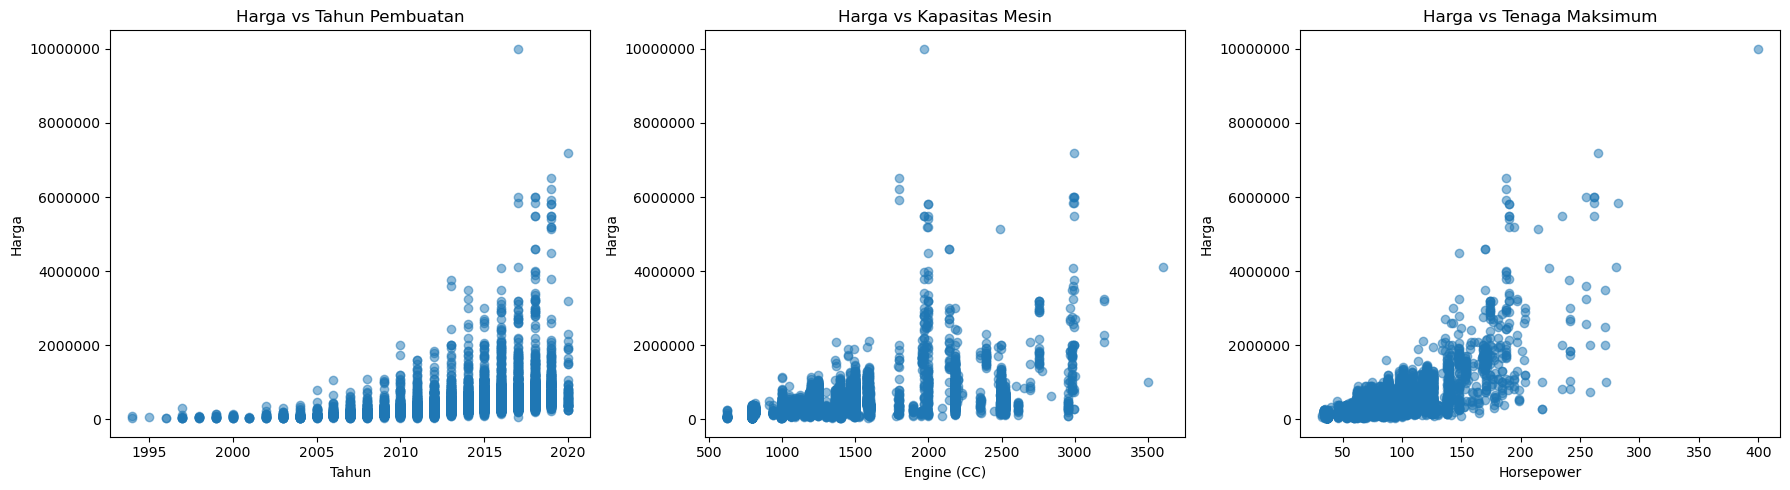

In [25]:
# scatter plot kolom numerik yang memiliki nilai korelasi > 0.4
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Harga vs Tahun
axes[0].scatter(df_eda['year'], df_eda['selling_price'], alpha=0.5)
axes[0].set_title('Harga vs Tahun Pembuatan', fontsize=12)
axes[0].set_xlabel('Tahun')
axes[0].set_ylabel('Harga')
axes[0].ticklabel_format(style='plain', axis='y')

# Harga vs Engine (mesin)
axes[1].scatter(df_eda['engine'], df_eda['selling_price'], alpha=0.5)
axes[1].set_title('Harga vs Kapasitas Mesin', fontsize=12)
axes[1].set_xlabel('Engine (CC)')
axes[1].set_ylabel('Harga')
axes[1].ticklabel_format(style='plain', axis='y')

# Harga vs Tenaga Maksimum
axes[2].scatter(df_eda['max_power'], df_eda['selling_price'], alpha=0.5)
axes[2].set_title('Harga vs Tenaga Maksimum', fontsize=12)
axes[2].set_xlabel('Horsepower')
axes[2].set_ylabel('Harga')
axes[2].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

## Insight

Dari visualisasi bar dapat kita lihat bahwa distribusi harga mobil bekas condong kearah kanan, yang dimana dari visualisasi box plot, terdapat banyak nilai outlier, dan ada 1 mobil yang memiliki harga sangat tinggi mencapai harga 10.000.000 Rupee. Rata-rata dari harga mobil bekas pada dataset ini ada di kisaran 500.000 Rupee.

Lalu kita ketahui juga bahwa faktor yang mempengaruhi sebuah harga mobil adalah tahun pembuatan mobil, kapasitas mesin, tenaga maksimum mobil tersebut yang mempengaruhi harga sebuah mobil bekas. Dari visualisasi scatter plot dapat dilihat bahwa semakin tinggi tahun, kapasitas, atau tenaga mobil, semakin tinggi juga harga mobil tersebut. Dan bisa dilihat bahwa dari visualisasi heatmap, kolom tahun memiliki korelasi yang paling kuat dengan kolom harga dibanding yang lain.

Perbedaan harga juga terjadi pada bahan bakar, yang dimana mobil berbahan bakar diesel lebih mahal daripada mobil berbahan bakar petrol. Dari visualisasi boxplot kita ketahui bahwa mobil diesel lebih banyakk dan memiliki range harga yang lebih mahal dibanding mobil petrol.

Dari dataset ini kita ketahui juga bahwa banyak sekali orang yang menjual mobil bekas dengan transmisi manual daripada automatic, dengan perbedaan yang sangat signifikan.

Semua analisa diatas memberikan informasi bahwa harga mobil bekas sangat terpengaruh oleh tahun pembuatan, kapasitas mesin dan tenaga mobil, dan apabila ada pelanggan ingin mencari mobil dengan rentang harga yang cukup murah, bisa mencari mobil yang berbahan bakar petrol daripada diesel. Kita ketahui juga masih banyak nilai-nilai harga cukup tinggi yang perlu kita perbaiki agar tidak mengganggu proses pembuatan model.

# Modeling 1 (Base)

In this section, we will train models using default parameters to see which one performs best before any tuning.

## Feature Engineering

### Handling Cardinality

In [26]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   object 
 1   year           6926 non-null   int64  
 2   selling_price  6926 non-null   int64  
 3   km_driven      6926 non-null   int64  
 4   fuel           6926 non-null   object 
 5   seller_type    6926 non-null   object 
 6   transmission   6926 non-null   object 
 7   owner          6926 non-null   object 
 8   mileage        6718 non-null   float64
 9   engine         6718 non-null   float64
 10  max_power      6720 non-null   float64
 11  seats          6718 non-null   float64
dtypes: float64(4), int64(3), object(5)
memory usage: 703.4+ KB


In [28]:
# Mengecek kardinalitas pada kolom kategorikal
catcols = list(df.select_dtypes(include='object').columns)

catlist = []
for c in catcols:
  catlist.append([c, df[c].nunique(), df[c].unique()])

pd.DataFrame(columns=['nama kolom', 'jumlah nilai unique', 'nilai unique'], data=catlist)

,nama kolom,jumlah nilai unique,nilai unique
0,name,2058,"[Maruti Swift Dzire VDI, Skoda Rapid 1.5 TDI A..."
1,fuel,4,"[Diesel, Petrol, LPG, CNG]"
2,seller_type,3,"[Individual, Dealer, Trustmark Dealer]"
3,transmission,2,"[Manual, Automatic]"
4,owner,5,"[First Owner, Second Owner, Third Owner, Fourt..."


There is a pattern in the car name column — we can extract the brand name from it as a new feature. The name column has very high cardinality, so we need to handle this to avoid hurting model performance later.

### Feature Creation

In [29]:
df[df['name'].str.contains('Ford')]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.00,1399.0,68.10,5.0
65,Ford Figo 1.2P Titanium MT,2017,600000,25000,Petrol,Individual,Manual,Third Owner,18.16,1196.0,86.80,5.0
81,Ford EcoSport 1.5 TDCi Titanium Plus BSIV,2015,610000,90000,Diesel,Individual,Manual,First Owner,22.77,1498.0,98.59,5.0
106,Ford Freestyle Titanium Petrol BSIV,2020,400000,5000,Petrol,Individual,Manual,Second Owner,19.00,1194.0,94.68,5.0
122,Ford EcoSport 1.5 Diesel Titanium Plus BSIV,2017,850000,76139,Diesel,Individual,Manual,First Owner,23.00,1498.0,98.96,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8082,Ford Fiesta 1.4 Duratorq EXI,2007,125000,110000,Diesel,Individual,Manual,Third Owner,17.80,1399.0,68.00,5.0
8095,Ford Figo Diesel Titanium,2012,260000,194000,Diesel,Individual,Manual,First Owner,20.00,1399.0,68.00,5.0
8097,Ford EcoSport 1.5 Diesel Titanium BSIV,2018,880000,65000,Diesel,Individual,Manual,First Owner,23.00,1498.0,98.96,5.0
8109,Ford Freestyle Titanium Plus Diesel BSIV,2018,750000,24000,Diesel,Individual,Manual,First Owner,24.40,1498.0,98.63,5.0


In [30]:
df['brand'] = df['name'].str.split().str[0]
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,Skoda
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,Honda
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,Hyundai
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,Maruti


In [31]:
df['brand'].nunique()

32

After creating the new feature, we can see that the dataset contains 32 different car brands. This feature should help the model make better predictions.

### Split between X and y

The target variable for this dataset is the selling_price column.

In [32]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

X.head(11)

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,brand
0,Maruti Swift Dzire VDI,2014,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,Skoda
2,Honda City 2017-2020 EXi,2006,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,Honda
3,Hyundai i20 Sportz Diesel,2010,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,Hyundai
4,Maruti Swift VXI BSIII,2007,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,Maruti
5,Hyundai Xcent 1.2 VTVT E Plus,2017,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,5.0,Hyundai
6,Maruti Wagon R LXI DUO BSIII,2007,175000,LPG,Individual,Manual,First Owner,17.30,1061.0,57.50,5.0,Maruti
7,Maruti 800 DX BSII,2001,5000,Petrol,Individual,Manual,Second Owner,16.10,796.0,37.00,4.0,Maruti
8,Toyota Etios VXD,2011,90000,Diesel,Individual,Manual,First Owner,23.59,1364.0,67.10,5.0,Toyota
9,Ford Figo Diesel Celebration Edition,2013,169000,Diesel,Individual,Manual,First Owner,20.00,1399.0,68.10,5.0,Ford


### Split between Train and Test set

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=77)

print('Train Size : ', X_train.shape[0])
print('Test Size : ', X_test.shape[0])

Train Size :  5540
Test Size :  1386


### Handling Missing Value

In [34]:
X_train.isnull().sum()

name              0
year              0
km_driven         0
fuel              0
seller_type       0
transmission      0
owner             0
mileage         160
engine          160
max_power       157
seats           160
brand             0
dtype: int64

In [35]:
X_test.isnull().sum()

name             0
year             0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage         48
engine          48
max_power       49
seats           48
brand            0
dtype: int64

In [ ]:
# handling missing value dengan nilai median
X_train_clean = X_train.fillna({
    'mileage' : X_train['mileage'].median(),
    'engine' : X_train['engine'].median(),
    'max_power' : X_train['max_power'].median(),
    'seats' : X_train['seats'].median()
})

X_test_clean = X_test.fillna({
    'mileage' : X_train['mileage'].median(),
    'engine' : X_train['engine'].median(),
    'max_power' : X_train['max_power'].median(),
    'seats' : X_train['seats'].median()
})

### Handling Outlier

In [37]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
year,5540.0,2013.464440,4.051661,1983.0,2011.0,2014.00,2017.00,2020.00
km_driven,5540.0,73684.440433,52251.201018,1.0,40000.0,70000.00,100000.00,1500000.00
mileage,5380.0,19.465128,4.065466,0.0,16.8,19.40,22.51,33.44
engine,5380.0,1430.933457,493.120454,624.0,1197.0,1248.00,1498.00,3198.00
max_power,5383.0,87.628283,31.371979,0.0,67.1,81.83,99.80,282.00
seats,5380.0,5.434758,0.988134,2.0,5.0,5.00,5.00,14.00


In [38]:
def deteksi_outlier_iqr(df, kolom):
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_bawah = Q1 - (1.5 * IQR)
    batas_atas = Q3 + (1.5 * IQR)
    
    outlier = df[(df[kolom] < batas_bawah) | (df[kolom] > batas_atas)]
    
    print(f"\n Kolom: {kolom}")
    print(f"Batas normal: {batas_bawah:.0f} - {batas_atas:.0f}")
    print(f"Jumlah outlier: {len(outlier)} ({len(outlier)/len(df)*100:.2f}%)")
    
    if len(outlier) > 0:
        print("Nilai outlier teratas:")
        print(outlier[kolom].sort_values(ascending=False).head(10).tolist())
    
    return outlier

In [39]:
numcols = X_train.select_dtypes(exclude='object').columns

for num in numcols :
    deteksi_outlier_iqr(X_train,num)


 Kolom: year
Batas normal: 2002 - 2026
Jumlah outlier: 60 (1.08%)
Nilai outlier teratas:
[2001, 2001, 2001, 2001, 2001, 2001, 2001, 2000, 2000, 2000]

 Kolom: km_driven
Batas normal: -50000 - 190000
Jumlah outlier: 132 (2.38%)
Nilai outlier teratas:
[1500000, 577414, 500000, 500000, 475000, 440000, 426000, 376412, 375000, 330000]

 Kolom: mileage
Batas normal: 8 - 31
Jumlah outlier: 19 (0.34%)
Nilai outlier teratas:
[33.44, 33.44, 33.0, 32.52, 32.26, 0.0, 0.0, 0.0, 0.0, 0.0]

 Kolom: engine
Batas normal: 746 - 1950
Jumlah outlier: 970 (17.51%)
Nilai outlier teratas:
[3198.0, 3198.0, 3198.0, 3198.0, 2999.0, 2999.0, 2997.0, 2997.0, 2993.0, 2993.0]

 Kolom: max_power
Batas normal: 18 - 149
Jumlah outlier: 252 (4.55%)
Nilai outlier teratas:
[282.0, 270.9, 270.9, 265.0, 261.4, 261.4, 258.0, 254.8, 254.8, 254.8]

 Kolom: seats
Batas normal: 5 - 5
Jumlah outlier: 1171 (21.14%)
Nilai outlier teratas:
[14.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]


There are many outlier values in the data. Since the percentage of outliers in several columns exceeds 5%, we will apply capping using Winsorizer to handle them.

In [40]:
# capping using winsorizer
cap = Winsorizer(capping_method='iqr',
                             tail='both',
                             fold=1.5,
                             variables=['year','km_driven','mileage','engine','max_power'])

X_train_cap = cap.fit_transform(X_train_clean)
X_test_cap = cap.transform(X_test_clean)

In [41]:
seats_cap = Winsorizer(capping_method='gaussian',
                             tail='both',
                             fold=1.5,
                             variables=['seats'])

X_train_cap = cap.fit_transform(X_train_cap)
X_test_cap = cap.transform(X_test_cap)

### Feature Selection

In [42]:
# melihat korelasi fitur numerik dengan target menggunakan metode spearman
p_value = []
hubungan = []
cols = []

for c in X_train_cap.select_dtypes(exclude='object').columns:
    cor, p = stats.spearmanr(X_train_cap[c], y_train)

    p_value.append(p)
    cols.append(c)

    if p < 0.05 :
        hubungan.append('ada hubungan')
    else :
        hubungan.append('tidak ada hubungan')

pd.DataFrame({
    'nama kolom' : cols,
    'hubungan' : hubungan,
    'p-value' : p_value
})

,nama kolom,hubungan,p-value
0,year,ada hubungan,0.000000e+00
1,km_driven,ada hubungan,1.471658e-113
2,mileage,tidak ada hubungan,7.604879e-02
3,engine,ada hubungan,0.000000e+00
4,max_power,ada hubungan,0.000000e+00
5,seats,ada hubungan,6.541832e-133


In [43]:
# melihat korelasi fitur kategorik dengan target menggunakan metode kendall
p_value = []
hubungan = []
cols = []

for c in X_train_cap.select_dtypes(include='object').columns:
    cor, p = stats.kendalltau(X_train_cap[c], y_train)

    p_value.append(p)
    cols.append(c)

    if p < 0.05 :
        hubungan.append('ada hubungan')
    else :
        hubungan.append('tidak ada hubungan')

pd.DataFrame({
    'nama kolom' : cols,
    'hubungan' : hubungan,
    'p-value' : p_value
})

,nama kolom,hubungan,p-value
0,name,tidak ada hubungan,3.909871e-01
1,fuel,ada hubungan,3.438687e-134
2,seller_type,ada hubungan,5.393835e-47
3,transmission,ada hubungan,2.594688e-120
4,owner,ada hubungan,3.111133e-170
5,brand,ada hubungan,1.775039e-03


In [44]:
# drop fitur yang tidak berkorelasi dengan target dan fitur yang sudah diwakilkan
X_train_cap.drop(columns=['name','mileage'], inplace=True)

# lakukan hal yang sama pada data test
X_test_cap.drop(columns=['name','mileage'], inplace=True)

### Split between Numerical and Categorical Columns

In [45]:
# pemisah kolom numerik dan kategorik
numcolumns = ['year', 'km_driven', 'engine', 'max_power', 'seats']
ohecatcolumns = ['fuel', 'seller_type', 'transmission']
ordcatcolumns = ['owner']
targetcatcolumns = ['brand']

### Pipeline for Scaling & Encoding

In [98]:
num_pipeline = make_pipeline(RobustScaler())

ohe_pipeline = make_pipeline(OneHotEncoder(handle_unknown="ignore", sparse_output=False))

ord_pipeline = make_pipeline(OrdinalEncoder(
    categories=[['Test Drive Car','First Owner',
                'Second Owner','Third Owner','Fourth & Above Owner']]))

te_pipeline = make_pipeline(ce.TargetEncoder(smoothing=20))

pre_pipeline = ColumnTransformer([
    ('pipe_num', num_pipeline, numcolumns),
    ('pipe_ohe', ohe_pipeline, ohecatcolumns),
    ('pipe_ord', ord_pipeline, ordcatcolumns),
    ('pipe_te', te_pipeline, targetcatcolumns)
])

## Model Definition

In [99]:
# menggunakan Pipeline
knn = Pipeline([('scaler',pre_pipeline),('knn',KNeighborsRegressor())])
svm = Pipeline([('scaler',pre_pipeline),('svm',SVR())])
dt = Pipeline([('scaler',pre_pipeline),('dt',DecisionTreeRegressor(random_state=45))])
rf = Pipeline([('scaler',pre_pipeline),('rf',RandomForestRegressor(random_state=45))])
xgb = Pipeline([('scaler',pre_pipeline),('xgb',XGBRegressor(random_state=45))])

In [100]:
# log transform target 

knn_log = TransformedTargetRegressor(
    regressor=knn,
    func=np.log1p,
    inverse_func=np.expm1
)

svm_log = TransformedTargetRegressor(
    regressor=svm,
    func=np.log1p,
    inverse_func=np.expm1
)

dt_log = TransformedTargetRegressor(
    regressor=dt,
    func=np.log1p,
    inverse_func=np.expm1
)

rf_log = TransformedTargetRegressor(
    regressor=rf,
    func=np.log1p,
    inverse_func=np.expm1
)

xgb_log = TransformedTargetRegressor(
    regressor=xgb,
    func=np.log1p,
    inverse_func=np.expm1
)

## Model Training

In [101]:
knn_log.fit(X_train_cap,y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('scaler',
                                                      ColumnTransformer(transformers=[('pipe_num',
                                                                                       Pipeline(steps=[('robustscaler',
                                                                                                        RobustScaler())]),
                                                                                       ['year',
                                                                                        'km_driven',
                                                                                        'engine',
                                                                                        'max_power',
                                                                                        'seats']),
                                                                                      ('pipe_ohe',
                                                                                       Pipeline(steps=[('onehotencoder',
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_outp...lse))]),
                                                                                       ['fuel',
                                                                                        'seller_type',
                                                                                        'transmission']),
                                                                                      ('pipe_ord',
                                                                                       Pipeline(steps=[('ordinalencoder',
                                                                                                        OrdinalEncoder(categories=[['Test '
                                                                                                                                    'Drive '
                                                                                                                                    'Car',
                                                                                                                                    'First '
                                                                                                                                    'Owner',
                                                                                                                                    'Second '
                                                                                                                                    'Owner',
                                                                                                                                    'Third '
                                                                                                                                    'Owner',
                                                                                                                                    'Fourth '
                                                                                                                                    '& '
                                                                                                                                    'Above '
                                                                                                                                    'Owner']]))]),
                                                                                       ['owner']),
                                                         

In [102]:
svm_log.fit(X_train_cap,y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('scaler',
                                                      ColumnTransformer(transformers=[('pipe_num',
                                                                                       Pipeline(steps=[('robustscaler',
                                                                                                        RobustScaler())]),
                                                                                       ['year',
                                                                                        'km_driven',
                                                                                        'engine',
                                                                                        'max_power',
                                                                                        'seats']),
                                                                                      ('pipe_ohe',
                                                                                       Pipeline(steps=[('onehotencoder',
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_output=False))]),
                                                                                       ['fuel',
                                                                                        'seller_type',
                                                                                        'transmission']),
                                                                                      ('pipe_ord',
                                                                                       Pipeline(steps=[('ordinalencoder',
                                                                                                        OrdinalEncoder(categories=[['Test '
                                                                                                                                    'Drive '
                                                                                                                                    'Car',
                                                                                                                                    'First '
                                                                                                                                    'Owner',
                                                                                                                                    'Second '
                                                                                                                                    'Owner',
                                                                                                                                    'Third '
                                                                                                                                    'Owner',
                                                                                                                                    'Fourth '
                                                                                                                                    '& '
                                                                                                                                    'Above '
                                                                                                                                    'Owner']]))]),
                                                                                       ['owner']),
                                                       

In [103]:
dt_log.fit(X_train_cap,y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('scaler',
                                                      ColumnTransformer(transformers=[('pipe_num',
                                                                                       Pipeline(steps=[('robustscaler',
                                                                                                        RobustScaler())]),
                                                                                       ['year',
                                                                                        'km_driven',
                                                                                        'engine',
                                                                                        'max_power',
                                                                                        'seats']),
                                                                                      ('pipe_ohe',
                                                                                       Pipeline(steps=[('onehotencoder',
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_outp...
                                                                                        'seller_type',
                                                                                        'transmission']),
                                                                                      ('pipe_ord',
                                                                                       Pipeline(steps=[('ordinalencoder',
                                                                                                        OrdinalEncoder(categories=[['Test '
                                                                                                                                    'Drive '
                                                                                                                                    'Car',
                                                                                                                                    'First '
                                                                                                                                    'Owner',
                                                                                                                                    'Second '
                                                                                                                                    'Owner',
                                                                                                                                    'Third '
                                                                                                                                    'Owner',
                                                                                                                                    'Fourth '
                                                                                                                                    '& '
                                                                                                                                    'Above '
                                                                                                                                    'Owner']]))]),
                                                                                       ['owner']),
                                                                                      ('pipe_te',
                                                               

In [104]:
rf_log.fit(X_train_cap,y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('scaler',
                                                      ColumnTransformer(transformers=[('pipe_num',
                                                                                       Pipeline(steps=[('robustscaler',
                                                                                                        RobustScaler())]),
                                                                                       ['year',
                                                                                        'km_driven',
                                                                                        'engine',
                                                                                        'max_power',
                                                                                        'seats']),
                                                                                      ('pipe_ohe',
                                                                                       Pipeline(steps=[('onehotencoder',
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_outp...
                                                                                        'seller_type',
                                                                                        'transmission']),
                                                                                      ('pipe_ord',
                                                                                       Pipeline(steps=[('ordinalencoder',
                                                                                                        OrdinalEncoder(categories=[['Test '
                                                                                                                                    'Drive '
                                                                                                                                    'Car',
                                                                                                                                    'First '
                                                                                                                                    'Owner',
                                                                                                                                    'Second '
                                                                                                                                    'Owner',
                                                                                                                                    'Third '
                                                                                                                                    'Owner',
                                                                                                                                    'Fourth '
                                                                                                                                    '& '
                                                                                                                                    'Above '
                                                                                                                                    'Owner']]))]),
                                                                                       ['owner']),
                                                                                      ('pipe_te',
                                                               

In [105]:
xgb_log.fit(X_train_cap,y_train)

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('scaler',
                                                      ColumnTransformer(transformers=[('pipe_num',
                                                                                       Pipeline(steps=[('robustscaler',
                                                                                                        RobustScaler())]),
                                                                                       ['year',
                                                                                        'km_driven',
                                                                                        'engine',
                                                                                        'max_power',
                                                                                        'seats']),
                                                                                      ('pipe_ohe',
                                                                                       Pipeline(steps=[('onehotencoder',
                                                                                                        OneHotEncoder(handle_unknown='ignore',
                                                                                                                      sparse_outp...
                                                                   grow_policy=None,
                                                                   importance_type=None,
                                                                   interaction_constraints=None,
                                                                   learning_rate=None,
                                                                   max_bin=None,
                                                                   max_cat_threshold=None,
                                                                   max_cat_to_onehot=None,
                                                                   max_delta_step=None,
                                                                   max_depth=None,
                                                                   max_leaves=None,
                                                                   min_child_weight=None,
                                                                   missing=nan,
                                                                   monotone_constraints=None,
                                                                   multi_strategy=None,
                                                                   n_estimators=None,
                                                                   n_jobs=None,
                                                                   num_parallel_tree=None,
                                                                   random_state=45, ...))]))

## Model Evaluation

In [106]:
# variabel prediksi untuk evaluasi model
knn_predict_train = knn_log.predict(X_train_cap)
svm_predict_train = svm_log.predict(X_train_cap)
dt_predict_train = dt_log.predict(X_train_cap)
rf_predict_train = rf_log.predict(X_train_cap)
xgb_predict_train = xgb_log.predict(X_train_cap)

knn_predict_test = knn_log.predict(X_test_cap)
svm_predict_test = svm_log.predict(X_test_cap)
dt_predict_test = dt_log.predict(X_test_cap)
rf_predict_test = rf_log.predict(X_test_cap)
xgb_predict_test = xgb_log.predict(X_test_cap)

cross_val_model_1 = cross_val_score(knn_log,
                                    X_train_cap,
                                    y_train,
                                    cv=5,
                                    scoring="r2")

cross_val_model_2 = cross_val_score(svm_log,
                                    X_train_cap,
                                    y_train,
                                    cv=5,
                                    scoring="r2")

cross_val_model_3 = cross_val_score(dt_log,
                                    X_train_cap,
                                    y_train,
                                    cv=5,
                                    scoring="r2")

cross_val_model_4 = cross_val_score(rf_log,
                                    X_train_cap,
                                    y_train,
                                    cv=5,
                                    scoring="r2")

cross_val_model_5 = cross_val_score(xgb_log,
                                    X_train_cap,
                                    y_train,
                                    cv=5,
                                    scoring="r2")

### KNN

In [107]:
knn_mae_train = mean_absolute_error(y_train, knn_predict_train)
knn_mae_test = mean_absolute_error(y_test, knn_predict_test)
knn_r2_train = r2_score(y_train, knn_predict_train)
knn_r2_test = r2_score(y_test, knn_predict_test)
knn_rmse_train = np.sqrt(mean_squared_error(y_train, knn_predict_train))
knn_rmse_test = np.sqrt(mean_squared_error(y_test, knn_predict_test))
knn_mape_train = mean_absolute_percentage_error(y_train, knn_predict_train)
knn_mape_test = mean_absolute_percentage_error(y_test, knn_predict_test)

print(f"KNN Train RMSE          :  {knn_rmse_train:.4f}")
print(f"KNN Test RMSE           :  {knn_rmse_test:.4f}")
print(f"KNN Train MAE           :  {knn_mae_train:.4f}")
print(f"KNN Test MAE            :  {knn_mae_test:.4f}")
print(f"KNN Train MAPE          :  {knn_mape_train*100:.2f}%")
print(f"KNN Test MAPE           :  {knn_mape_test*100:.2f}%")
print(f"KNN Train R2            :  {knn_r2_train:.2f}")
print(f"KNN Test R2             :  {knn_r2_test:.2f}")
print('Mean - Cross Validation : ', cross_val_model_1.mean())
print('Std - Cross Validation  : ', cross_val_model_1.std())

KNN Train RMSE          :  183726.0572
KNN Test RMSE           :  309293.5900
KNN Train MAE           :  83711.6322
KNN Test MAE            :  105330.5348
KNN Train MAPE          :  17.50%
KNN Test MAPE           :  21.46%
KNN Train R2            :  0.87
KNN Test R2             :  0.69
Mean - Cross Validation :  0.7965994585653773
Std - Cross Validation  :  0.041220059049393236


### SVM

In [108]:
svm_mae_train = mean_absolute_error(y_train, svm_predict_train)
svm_mae_test = mean_absolute_error(y_test, svm_predict_test)
svm_r2_train = r2_score(y_train, svm_predict_train)
svm_r2_test = r2_score(y_test, svm_predict_test)
svm_rmse_train = np.sqrt(mean_squared_error(y_train, svm_predict_train))
svm_rmse_test = np.sqrt(mean_squared_error(y_test, svm_predict_test))
svm_mape_train = mean_absolute_percentage_error(y_train, svm_predict_train)
svm_mape_test = mean_absolute_percentage_error(y_test, svm_predict_test)

print(f"SVM Train RMSE          :  {svm_rmse_train:.4f}")
print(f"SVM Test RMSE           :  {svm_rmse_test:.4f}")
print(f"SVM Train MAE           :  {svm_mae_train:.4f}")
print(f"SVM Test MAE            :  {svm_mae_test:.4f}")
print(f"SVM Train MAPE          :  {svm_mape_train*100:.2f}%")
print(f"SVM Test MAPE           :  {svm_mape_test*100:.2f}%")
print(f"SVM Train R2            :  {svm_r2_train:.2f}")
print(f"SVM Test R2             :  {svm_r2_test:.2f}")
print('Mean - Cross Validation : ', cross_val_model_2.mean())
print('Std - Cross Validation  : ', cross_val_model_2.std())

SVM Train RMSE          :  232820.3089
SVM Test RMSE           :  326112.4109
SVM Train MAE           :  106591.9649
SVM Test MAE            :  110883.9669
SVM Train MAPE          :  22.30%
SVM Test MAPE           :  21.97%
SVM Train R2            :  0.79
SVM Test R2             :  0.66
Mean - Cross Validation :  0.7727392405082264
Std - Cross Validation  :  0.0231591404631948


### Decision Tree

In [109]:
dt_mae_train = mean_absolute_error(y_train, dt_predict_train)
dt_mae_test = mean_absolute_error(y_test, dt_predict_test)
dt_r2_train = r2_score(y_train, dt_predict_train)
dt_r2_test = r2_score(y_test, dt_predict_test)
dt_rmse_train = np.sqrt(mean_squared_error(y_train, dt_predict_train))
dt_rmse_test = np.sqrt(mean_squared_error(y_test, dt_predict_test))
dt_mape_train = mean_absolute_percentage_error(y_train, dt_predict_train)
dt_mape_test = mean_absolute_percentage_error(y_test, dt_predict_test)

print(f"Decision tree Train RMSE  :  {dt_rmse_train:.4f}")
print(f"Decision tree Test RMSE   :  {dt_rmse_test:.4f}")
print(f"Decision tree Train MAE   :  {dt_mae_train:.4f}")
print(f"Decision tree Test MAE    :  {dt_mae_test:.4f}")
print(f"Decision tree Train MAPE  :  {dt_mape_train*100:.2f}%")
print(f"Decision tree Test MAPE   :  {dt_mape_test*100:.2f}%")
print(f"Decision tree Train R2    :  {dt_r2_train:.2f}")
print(f"Decision tree Test R2     :  {dt_r2_test:.2f}")
print('Mean - Cross Validation   : ', cross_val_model_3.mean())
print('Std - Cross Validation    : ', cross_val_model_3.std())

Decision tree Train RMSE  :  24503.5564
Decision tree Test RMSE   :  234419.4178
Decision tree Train MAE   :  5842.3163
Decision tree Test MAE    :  106475.1791
Decision tree Train MAPE  :  1.31%
Decision tree Test MAPE   :  22.98%
Decision tree Train R2    :  1.00
Decision tree Test R2     :  0.82
Mean - Cross Validation   :  0.8039995359310221
Std - Cross Validation    :  0.038290067824360244


### Random Forest

In [110]:
rf_mae_train = mean_absolute_error(y_train, rf_predict_train)
rf_mae_test = mean_absolute_error(y_test, rf_predict_test)
rf_r2_train = r2_score(y_train, rf_predict_train)
rf_r2_test = r2_score(y_test, rf_predict_test)
rf_rmse_train = np.sqrt(mean_squared_error(y_train, rf_predict_train))
rf_rmse_test = np.sqrt(mean_squared_error(y_test, rf_predict_test))
rf_mape_train = mean_absolute_percentage_error(y_train, rf_predict_train)
rf_mape_test = mean_absolute_percentage_error(y_test, rf_predict_test)

print(f"Random Forest Train RMSE  :  {rf_rmse_train:.4f}")
print(f"Random Forest Test RMSE   :  {rf_rmse_test:.4f}")
print(f"Random Forest Train MAE   :  {rf_mae_train:.4f}")
print(f"Random Forest Test MAE    :  {rf_mae_test:.4f}")
print(f"Random Forest Train MAPE  :  {rf_mape_train*100:.2f}%")
print(f"Random Forest Test MAPE   :  {rf_mape_test*100:.2f}%")
print(f"Random Forest Train R2    :  {rf_r2_train:.2f}")
print(f"Random Forest Test R2     :  {rf_r2_test:.2f}")
print('Mean - Cross Validation   : ', cross_val_model_4.mean())
print('Std - Cross Validation    : ', cross_val_model_4.std())

Random Forest Train RMSE  :  69603.1103
Random Forest Test RMSE   :  241533.6493
Random Forest Train MAE   :  33908.0397
Random Forest Test MAE    :  84363.2776
Random Forest Train MAPE  :  6.94%
Random Forest Test MAPE   :  17.34%
Random Forest Train R2    :  0.98
Random Forest Test R2     :  0.81
Mean - Cross Validation   :  0.8738277739623397
Std - Cross Validation    :  0.031145437092025198


### XGBoost

In [111]:
xgb_mae_train = mean_absolute_error(y_train, xgb_predict_train)
xgb_mae_test = mean_absolute_error(y_test, xgb_predict_test)
xgb_r2_train = r2_score(y_train, xgb_predict_train)
xgb_r2_test = r2_score(y_test, xgb_predict_test)
xgb_rmse_train = np.sqrt(mean_squared_error(y_train, xgb_predict_train))
xgb_rmse_test = np.sqrt(mean_squared_error(y_test, xgb_predict_test))
xgb_mape_train = mean_absolute_percentage_error(y_train, xgb_predict_train)
xgb_mape_test = mean_absolute_percentage_error(y_test, xgb_predict_test)

print(f"XGBoost Train RMSE      :  {xgb_rmse_train:.4f}")
print(f"XGBoost Test RMSE       :  {xgb_rmse_test:.4f}")
print(f"XGBoost Train MAE       :  {xgb_mae_train:.4f}")
print(f"XGBoost Test MAE        :  {xgb_mae_test:.4f}")
print(f"XGBoost Train MAPE      :  {xgb_mape_train*100:.2f}%")
print(f"XGBoost Test MAPE       :  {xgb_mape_test*100:.2f}%")
print(f"XGBoost Train R2        :  {xgb_r2_train:.2f}")
print(f"XGBoost Test R2         :  {xgb_r2_test:.2f}")
print('Mean - Cross Validation : ', cross_val_model_5.mean())
print('Std - Cross Validation  : ', cross_val_model_5.std())

XGBoost Train RMSE      :  80681.1714
XGBoost Test RMSE       :  227316.7648
XGBoost Train MAE       :  46965.6408
XGBoost Test MAE        :  81244.7629
XGBoost Train MAPE      :  10.08%
XGBoost Test MAPE       :  17.01%
XGBoost Train R2        :  0.97
XGBoost Test R2         :  0.83
Mean - Cross Validation :  0.8866262555122375
Std - Cross Validation  :  0.028820506431884406


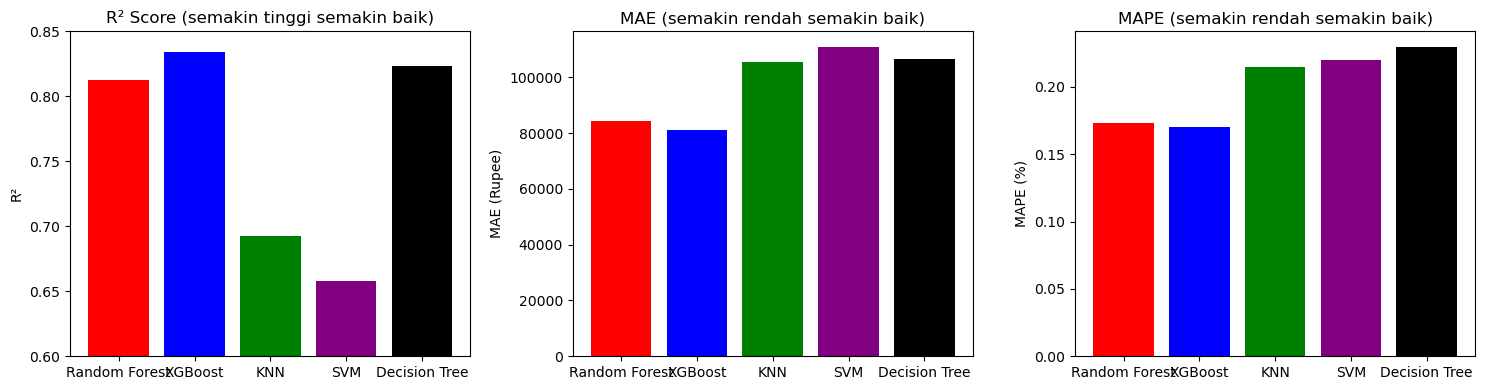

In [140]:
# Perbandingan model dari R2 score, MAE score dan MAPE score 
models = ['Random Forest', 'XGBoost', 'KNN', 'SVM', 'Decision Tree']
r2_scores = [rf_r2_test, xgb_r2_test, knn_r2_test, svm_r2_test, dt_r2_test]
mae_scores = [rf_mae_test, xgb_mae_test, knn_mae_test, svm_mae_test, dt_mae_test]
mape_scores = [rf_mape_test, xgb_mape_test, knn_mape_test, svm_mape_test, dt_mape_test]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# R² Bar
axes[0].bar(models, r2_scores, color=['red', 'blue', 'green', 'purple', 'black'])
axes[0].set_title('R² Score (semakin tinggi semakin baik)')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.6, 0.85)

# MAE Bar
axes[1].bar(models, mae_scores, color=['red', 'blue', 'green', 'purple','black'])
axes[1].set_title('MAE (semakin rendah semakin baik)')
axes[1].set_ylabel('MAE (Rupee)')

# MAPE Bar
axes[2].bar(models, mape_scores, color=['red', 'blue', 'green', 'purple', 'black'])
axes[2].set_title('MAPE (semakin rendah semakin baik)')
axes[2].set_ylabel('MAPE (%)')

plt.tight_layout()
plt.show()

From the bar charts above, we can see that the best performing base models are Random Forest and XGBoost. They have the highest R² scores, lowest MAE, and lowest MAPE values. Even without any tuning, both models have a very small cross-validation standard deviation, which means their predictions are fairly stable and not too biased. However, we still need to check the residual plots for both models to better understand their behavior.

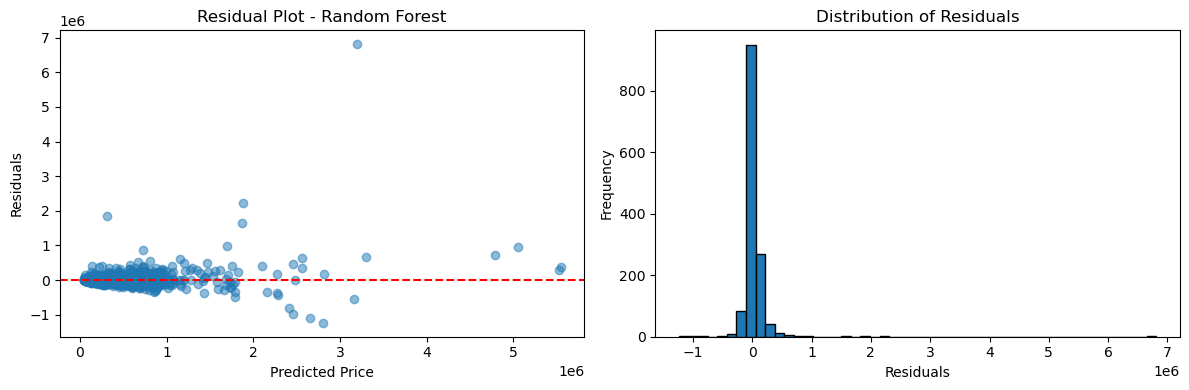

In [112]:
# residual plot Random Forest
residuals = y_test - rf_predict_test

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(rf_predict_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot - Random Forest')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')

plt.tight_layout()
plt.show()

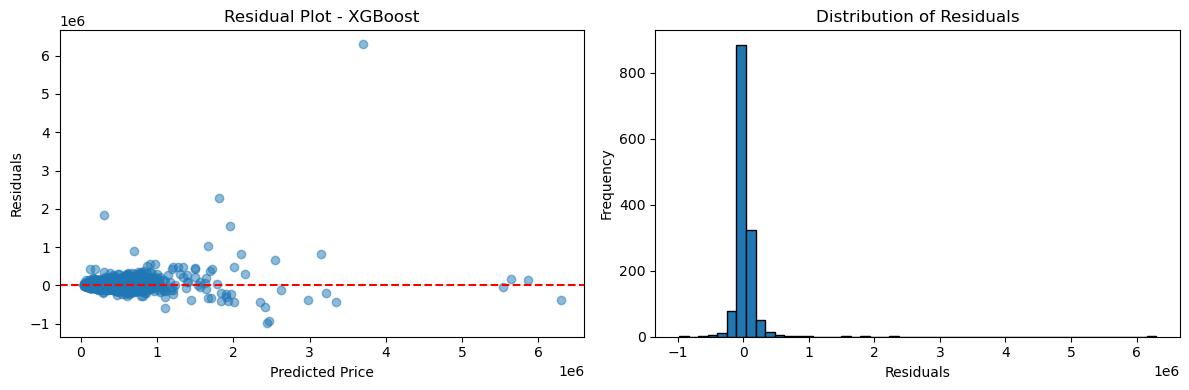

In [113]:
# Residual plot Xgboost
residuals2 = y_test - xgb_predict_test

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(xgb_predict_test, residuals2, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot - XGBoost')

plt.subplot(1, 2, 2)
plt.hist(residuals2, bins=50, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')

plt.tight_layout()
plt.show()

From the residual plots of both Random Forest and XGBoost, we can see that the predictions are reasonably tight, but the residual spread is not consistent across all predicted values. Both models perform well for mid-to-low priced cars, but tend to struggle with more expensive cars — the residuals become more scattered above prices of around 1,500,000 Rupee. This suggests some bias for high-value cars. To address this, let's try combining these two top-performing models using a stacking approach.

# Modeling 2 (Stacking)

In this section, we will combine Random Forest and XGBoost into a single stacking model. We also add a Ridge regression model as the final estimator to help smooth out the predictions and make the overall model more stable.

## Model Training

In [131]:
# Model Definition
ensamble = StackingRegressor(estimators=[('rf', rf_log), ('xgb', xgb_log)],final_estimator=Ridge(alpha=1.0),cv=5)

# Model Training
ensamble.fit(X_train_cap,y_train)

StackingRegressor(cv=5,
                  estimators=[('rf',
                               TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                          inverse_func=<ufunc 'expm1'>,
                                                          regressor=Pipeline(steps=[('scaler',
                                                                                     ColumnTransformer(transformers=[('pipe_num',
                                                                                                                      Pipeline(steps=[('robustscaler',
                                                                                                                                       RobustScaler())]),
                                                                                                                      ['year',
                                                                                                                       'km_driven',
                                                                                                                       'engine',
                                                                                                                       'max_power',
                                                                                                                       'seats']),
                                                                                                                     ('pipe_ohe',
                                                                                                                      Pipeline(steps=[('onehotencoder',
                                                                                                                                       OneHotEn...
                                                                                                  importance_type=None,
                                                                                                  interaction_constraints=None,
                                                                                                  learning_rate=None,
                                                                                                  max_bin=None,
                                                                                                  max_cat_threshold=None,
                                                                                                  max_cat_to_onehot=None,
                                                                                                  max_delta_step=None,
                                                                                                  max_depth=None,
                                                                                                  max_leaves=None,
                                                                                                  min_child_weight=None,
                                                                                                  missing=nan,
                                                                                                  monotone_constraints=None,
                                                                                                  multi_strategy=None,
                                                                                                  n_estimators=None,
                                                                                                  n_jobs=None,
                                                                                                  num_parallel_tree=None,
                                                                                                  random_state=45, ...))])))],
                  final_estimator=Ridge())

## Model Evaluation

In [132]:
# Cek CV score dan Predict
ens_predict_train = ensamble.predict(X_train_cap)
ens_predict_test = ensamble.predict(X_test_cap)
cross_val_model_6 = cross_val_score(ensamble,
                                    X_train_cap,
                                    y_train,
                                    cv=5,
                                    scoring="r2")

In [133]:
# Metrik Evaluasi
ens_mae_train = mean_absolute_error(y_train, ens_predict_train)
ens_mae_test = mean_absolute_error(y_test, ens_predict_test)
ens_r2_train = r2_score(y_train, ens_predict_train)
ens_r2_test = r2_score(y_test, ens_predict_test)
ens_rmse_train = np.sqrt(mean_squared_error(y_train, ens_predict_train))
ens_rmse_test = np.sqrt(mean_squared_error(y_test, ens_predict_test))
ens_mape_train = mean_absolute_percentage_error(y_train, ens_predict_train)
ens_mape_test = mean_absolute_percentage_error(y_test, ens_predict_test)

print(f"Ensamble Train RMSE          :  {ens_rmse_train:.4f}")
print(f"Ensamble Test RMSE           :  {ens_rmse_test:.4f}")
print(f"Ensamble Train MAE           :  {ens_mae_train:.4f}")
print(f"Ensamble Test MAE            :  {ens_mae_test:.4f}")
print(f"Ensamble Train MAPE          :  {ens_mape_train*100:.2f}%")
print(f"Ensamble Test MAPE           :  {ens_mape_test*100:.2f}%")
print(f"Ensamble Train R2            :  {ens_r2_train:.2f}")
print(f"Ensamble Test R2             :  {ens_r2_test:.2f}")
print('Mean - Cross Validation      : ', cross_val_model_6.mean())
print('Std - Cross Validation       : ', cross_val_model_6.std())

Ensamble Train RMSE          :  73008.9397
Ensamble Test RMSE           :  225903.3473
Ensamble Train MAE           :  42740.3333
Ensamble Test MAE            :  80242.7822
Ensamble Train MAPE          :  9.22%
Ensamble Test MAPE           :  16.93%
Ensamble Train R2            :  0.98
Ensamble Test R2             :  0.84
Mean - Cross Validation      :  0.8871925797629723
Std - Cross Validation       :  0.029104855471523534


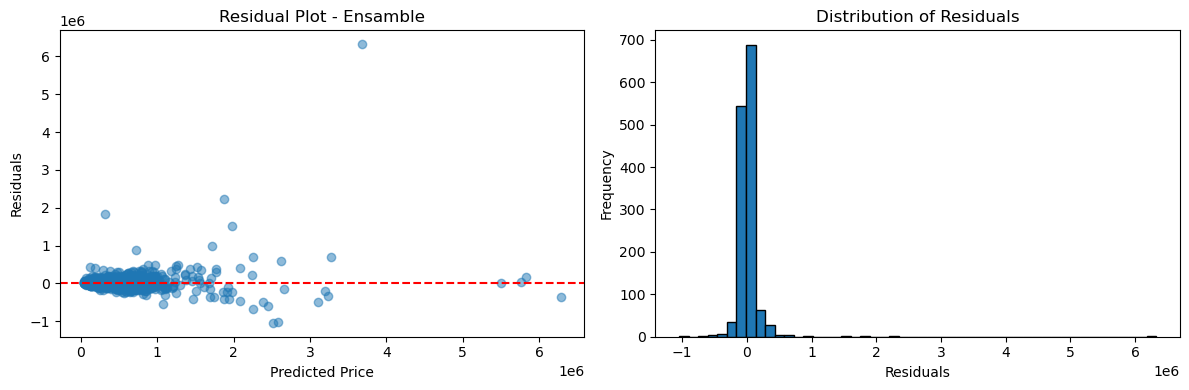

In [134]:
# Residual plot hasil model gabungan Random Forest dan Xgboost
residuals3 = y_test - ens_predict_test

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(ens_predict_test, residuals3, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot - Ensamble')

plt.subplot(1, 2, 2)
plt.hist(residuals3, bins=50, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')

plt.tight_layout()
plt.show()

The stacking model gives better evaluation results compared to individual Random Forest and XGBoost models. The R² score increased, MAPE percentage decreased, and the residual plot shows that predictions for higher-priced cars are now closer to the actual values. The residual distribution is also more balanced. Stacking effectively combines XGBoost's accuracy with Random Forest's stability — the weaknesses of one model are compensated by the other. Next, we will apply hyperparameter tuning to find the best parameters for this stacking model.

# Hyperparameter Tuning

##  Training

In [ ]:
param = {
    # PARAMETER UNTUK RANDOM FOREST
    'rf__regressor__rf__n_estimators': [100, 200, 300],
    'rf__regressor__rf__max_depth': [10, 15, 20, None],
    'rf__regressor__rf__min_samples_split': [5, 10, 20],
    'rf__regressor__rf__min_samples_leaf': [2, 4, 8],
    'rf__regressor__rf__max_features': ['sqrt', 'log2'],
    
    # PARAMETER UNTUK XGBOOST
    'xgb__regressor__xgb__n_estimators': [100, 200, 300],
    'xgb__regressor__xgb__max_depth': [3, 5, 7, 9],
    'xgb__regressor__xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__regressor__xgb__subsample': [0.8, 1.0],
    'xgb__regressor__xgb__colsample_bytree': [0.8, 1.0],
    'xgb__regressor__xgb__reg_alpha': [0, 0.1, 1.0],     
    'xgb__regressor__xgb__reg_lambda': [1.0, 2.0],        
    
    # PARAMETER UNTUK RIDGE
    'final_estimator__alpha': [0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
    'final_estimator__fit_intercept': [True, False],
    
    # PARAMETER UNTUK STACKING
    'cv': [3, 5],  # jumlah fold
}

We will use RandomizedSearchCV to search for the best hyperparameter combination.

In [157]:
random_search = RandomizedSearchCV(
    ensamble,
    param_distributions=param,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=45
)

random_search.fit(X_train_cap,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=StackingRegressor(cv=5,
                                               estimators=[('rf',
                                                            TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                                                       inverse_func=<ufunc 'expm1'>,
                                                                                       regressor=Pipeline(steps=[('scaler',
                                                                                                                  ColumnTransformer(transformers=[('pipe_num',
                                                                                                                                                   Pipeline(steps=[('robustscaler',
                                                                                                                                                                    RobustScaler())]),
                                                                                                                                                   ['year',
                                                                                                                                                    'km_driven',
                                                                                                                                                    'engine',
                                                                                                                                                    'max_power',
                                                                                                                                                    'seats']),
                                                                                                                                                  ('pipe_ohe',
                                                                                                                                                   Pipelin...
                                        'xgb__regressor__xgb__colsample_bytree': [0.8,
                                                                                  1.0],
                                        'xgb__regressor__xgb__learning_rate': [0.01,
                                                                               0.05,
                                                                               0.1],
                                        'xgb__regressor__xgb__max_depth': [3, 5,
                                                                           7,
                                                                           9],
                                        'xgb__regressor__xgb__n_estimators': [100,
                                                                              200,
                                                                              300],
                                        'xgb__regressor__xgb__reg_alpha': [0,
                                                                           0.1,
                                                                           1.0],
                                        'xgb__regressor__xgb__reg_lambda': [1.0,
                                                                            2.0],
                                        'xgb__regressor__xgb__subsample': [0.8,
                                                                           1.0]},
                   random_state=45, scoring='r2', verbose=2)

## Evaluation

In [158]:
# best paramater
random_search.best_params_

{'xgb__regressor__xgb__subsample': 1.0,
 'xgb__regressor__xgb__reg_lambda': 2.0,
 'xgb__regressor__xgb__reg_alpha': 0,
 'xgb__regressor__xgb__n_estimators': 100,
 'xgb__regressor__xgb__max_depth': 7,
 'xgb__regressor__xgb__learning_rate': 0.1,
 'xgb__regressor__xgb__colsample_bytree': 0.8,
 'rf__regressor__rf__n_estimators': 200,
 'rf__regressor__rf__min_samples_split': 10,
 'rf__regressor__rf__min_samples_leaf': 8,
 'rf__regressor__rf__max_features': 'log2',
 'rf__regressor__rf__max_depth': 10,
 'final_estimator__fit_intercept': True,
 'final_estimator__alpha': 2.0,
 'cv': 5}

In [159]:
# Get Best Estimator
best_model = random_search.best_estimator_

In [160]:
best_predict_train = best_model.predict(X_train_cap)
best_predict_test = best_model.predict(X_test_cap)
cross_val_model_7 = cross_val_score(best_model,
                                    X_train_cap,
                                    y_train,
                                    cv=5,
                                    scoring="r2")

In [161]:
# Metrik Evaluasi
best_mae_train = mean_absolute_error(y_train, best_predict_train)
best_mae_test = mean_absolute_error(y_test, best_predict_test)
best_r2_train = r2_score(y_train, best_predict_train)
best_r2_test = r2_score(y_test, best_predict_test)
best_rmse_train = np.sqrt(mean_squared_error(y_train, best_predict_train))
best_rmse_test = np.sqrt(mean_squared_error(y_test, best_predict_test))
best_mape_train = mean_absolute_percentage_error(y_train, best_predict_train)
best_mape_test = mean_absolute_percentage_error(y_test, best_predict_test)

print(f"Best Model Train RMSE          :  {best_rmse_train:.4f}")
print(f"Best Model Test RMSE           :  {best_rmse_test:.4f}")
print(f"Best Model Train MAE           :  {best_mae_train:.4f}")
print(f"Best Model Test MAE            :  {best_mae_test:.4f}")
print(f"Best Model Train MAPE          :  {best_mape_train*100:.2f}%")
print(f"Best Model Test MAPE           :  {best_mape_test*100:.2f}%")
print(f"Best Model Train R2            :  {best_r2_train:.2f}")
print(f"Best Model Test R2             :  {best_r2_test:.2f}")
print('Mean - Cross Validation        : ', cross_val_model_7.mean())
print('Std - Cross Validation         : ', cross_val_model_7.std())

Best Model Train RMSE          :  95909.4516
Best Model Test RMSE           :  227525.0302
Best Model Train MAE           :  55091.7634
Best Model Test MAE            :  79538.7908
Best Model Train MAPE          :  12.18%
Best Model Test MAPE           :  16.86%
Best Model Train R2            :  0.96
Best Model Test R2             :  0.83
Mean - Cross Validation        :  0.8969768235003839
Std - Cross Validation         :  0.026512469028529162


### Comparison Model Before and After Tuning

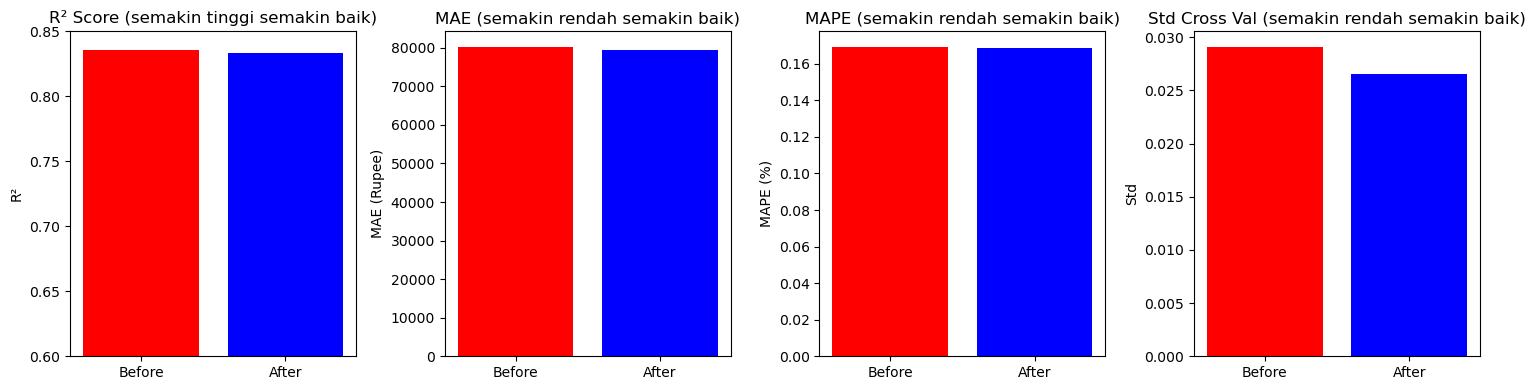

In [171]:
# Perbandingan model dari R2 score, MAE score dan MAPE score 
models = ['Before', 'After']
r2_scores = [ens_r2_test, best_r2_test]
mae_scores = [ens_mae_test, best_mae_test]
mape_scores = [ens_mape_test, best_mape_test]
std_cross_val = [cross_val_model_6.std(),cross_val_model_7.std()]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# R² Bar
axes[0].bar(models, r2_scores, color=['red', 'blue'])
axes[0].set_title('R² Score (semakin tinggi semakin baik)')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.6, 0.85)

# MAE Bar
axes[1].bar(models, mae_scores, color=['red', 'blue'])
axes[1].set_title('MAE (semakin rendah semakin baik)')
axes[1].set_ylabel('MAE (Rupee)')

# MAPE Bar
axes[2].bar(models, mape_scores, color=['red', 'blue'])
axes[2].set_title('MAPE (semakin rendah semakin baik)')
axes[2].set_ylabel('MAPE (%)')

# MAPE Bar
axes[3].bar(models, std_cross_val, color=['red', 'blue'])
axes[3].set_title('Std Cross Val (semakin rendah semakin baik)')
axes[3].set_ylabel('Std')

plt.tight_layout()
plt.show()

Looking at the before-and-after comparison in the bar charts above, we can see that after tuning, the MAE, MAPE percentage, and cross-validation standard deviation all decreased. This means the tuned model is more accurate and more stable. Although the R² score is slightly lower after tuning, the gap between train and test error becomes smaller — which means the model is less overfitted. The improvement may not look dramatic because the base model was already performing reasonably well, but tuning helped reduce overfitting and made the model more reliable on unseen data.

# Business Recommendation

Based on the model we have built, here are some practical recommendations for the used car company:

**1. Use the model as a pricing tool for sellers**
The model can be integrated into the company's platform to give sellers an objective price estimate before they list their car. This helps avoid cars being priced too high (which scares away buyers) or too low (which hurts the seller).

**2. Focus on high-impact features when collecting car data**
The analysis shows that manufacturing year, engine capacity, and max power are the strongest predictors of price. When collecting car listings, make sure these fields are always filled in completely and accurately — missing values in these columns will reduce the model's prediction quality.

**3. Be cautious with high-value car pricing**
The model performs best for mid-to-low priced cars (under 1,500,000 Rupee). For premium or luxury cars, the model's prediction may be less accurate. The company should consider adding manual review by an expert for cars in this price segment.

**4. Diesel vs Petrol pricing strategy**
Since diesel cars consistently price higher than petrol cars, the company can use this insight to create separate pricing tiers or category filters on their platform — helping buyers find cars within their budget more easily.

**5. Leverage ownership history as a trust signal**
The data shows that ownership history (first owner, second owner, etc.) affects price. The company can highlight "First Owner" cars as a premium listing feature to attract buyers who value car history.

**6. Regularly retrain the model**
Car market prices change over time due to inflation, new car releases, and shifting demand. It is recommended to retrain the model periodically (e.g., every 6 months) with fresh data to keep predictions accurate and relevant.

# Model Saving

In [173]:
pickle.dump(best_model, open('best_model.pkl', 'wb'))